# Approach 14: Hybrid FM + PINN

Fuses ECGFounder embeddings (1024-d) with the 17-parameter output of the McSharry PINN from Approach 10. Both branches are projected to 128-d and concatenated before a small MLP head.

The PINN is used here as a frozen feature extractor. Physics supervision happened during Approach 10 training; this notebook does not impose any physics loss. The PINN is trained on 12-lead input, so its 17 outputs are a learned per-record summary, not single-lead McSharry parameters in the classical sense.

SaMi-Trop is reported as external validation only (all-positive, AUROC undefined). The 15% CODE-15 split is the held-out test set.

In [1]:
import math
import os
import sys
import time
import logging
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    f1_score, roc_curve, precision_recall_curve,
)
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

sns.set_context("notebook")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("chagas")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"PyTorch {torch.__version__} | Device : {device}")

_SEED = 42
torch.manual_seed(_SEED)
np.random.seed(_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(_SEED)

torch.use_deterministic_algorithms(True, warn_only=False)

/Users/jwasieleski/Prywatne/jul/workspace/magisterka/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.10.0 | Device : mps


In [2]:
CFG = {
    "preprocessed_cache": "preprocessed_cache_brazil.h5",
    "val_fraction": 0.15,
    "test_fraction": 0.15,
    "random_seed": 42,
    "target_fs": 500,
    "target_duration_s": 10,

    "ecgfounder_path": "ECGFounder",
    "fm_weights_path": "ECGFounder/weights/12_lead_ECGFounder.pth",

    "pinn_weights_path": "approach10_mcsharry_best.pt",
    "pinn_cfg": {
        "in_channels": 12,
        "base_ch": 64,
        "kernel_size": 15,
        "dropout": 0.2,
        "num_adap_blocks": 4,
    },

    "epochs": 20,
    "batch_size": 64,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "grad_clip": 1.0,
    "num_workers": 0,

    "focal_alpha": None,
    "focal_gamma": 2.0,
}

In [ ]:
sys.path.append(os.path.abspath(CFG["ecgfounder_path"]))
from net1d import Net1D

def load_ecgfounder(weights_path, device):
    model = Net1D(
        in_channels=12,
        base_filters=64,
        ratio=1,
        filter_list=[64,160,160,400,400,1024,1024],
        m_blocks_list=[2,2,2,3,3,4,4],
        kernel_size=16,
        stride=2,
        groups_width=16,
        verbose=False,
        use_bn=False,
        use_do=False,
        n_classes=150
    )

    checkpoint = torch.load(weights_path, map_location=device, weights_only=False)
    state_dict = checkpoint.get("state_dict", checkpoint)

    model.load_state_dict(state_dict, strict=True)
    logger.info("ECGFounder weights loaded with strict=True")

    _head_candidates = ("fc", "dense", "classifier", "linear", "head", "output_layer", "out")
    replaced = False
    for name in _head_candidates:
        if hasattr(model, name):
            setattr(model, name, nn.Identity())
            logger.info(f"Replaced classification head '{name}' with Identity")
            replaced = True
            break
    if not replaced:
        logger.warning(
            "No known classification head attribute found on Net1D. "
            "The model may still output class logits instead of embeddings. "
            "Inspect model.named_modules() and set the correct attribute to nn.Identity()."
        )

    model.eval()
    model.to(device)

    with torch.no_grad():
        _dummy = torch.zeros(1, 12, 5000, device=device)
        _out = model(_dummy)
    assert _out.shape[-1] == 1024, (
        f"Expected FM embedding dim=1024 but got {_out.shape[-1]}. "
        f"The classification head was {'replaced' if replaced else 'NOT replaced'} "
        f"inspect model architecture and update load_ecgfounder accordingly."
    )
    logger.info(f"FM embedding verified: output shape {tuple(_out.shape)}")

    return model

logger.info(f"Loading ECGFounder from {CFG['fm_weights_path']}")
fm_model = load_ecgfounder(CFG["fm_weights_path"], device)
for param in fm_model.parameters():
    param.requires_grad = False

In [4]:

class AdapResBlock1D(nn.Module):
    def __init__(self, ch, kernel_size=15, dropout=0.2):
        super().__init__()
        pad = kernel_size // 2
        self.conv = nn.Sequential(
            nn.Conv1d(ch, ch, kernel_size, padding=pad, bias=False),
            nn.GroupNorm(8, ch),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(ch, ch, kernel_size, padding=pad, bias=False),
            nn.GroupNorm(8, ch),
        )
        self.alpha = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return x + self.alpha * self.conv(x)

class McSharryPINN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        c = cfg["base_ch"]
        self.stem = nn.Sequential(
            nn.Conv1d(cfg["in_channels"], c, kernel_size=cfg["kernel_size"],
                      padding=cfg["kernel_size"] // 2, bias=False),
            nn.GroupNorm(8, c),
            nn.GELU(),
        )
        self.blocks = nn.ModuleList(
            [AdapResBlock1D(c, cfg["kernel_size"], cfg["dropout"])
             for _ in range(cfg["num_adap_blocks"])]
        )
        self.down = nn.Conv1d(c, c, kernel_size=4, stride=2, padding=1, bias=False)
        self.proj = nn.Sequential(nn.GroupNorm(8, c), nn.GELU())
        self.ode_head = nn.Linear(c, 17)
        self.clf = nn.Sequential(
            nn.Linear(17, 32),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x, return_params=False):
        h = self.stem(x)
        for blk in self.blocks:
            h = blk(h)
        h = self.down(h)
        h = self.proj(h)
        ctx = h.mean(dim=-1)
        raw = self.ode_head(ctx)

        f  = torch.sigmoid(raw[:, 0:1]) * 2.0 + 0.5
        z0 = torch.tanh(raw[:, 1:2]) * 0.5
        A  = torch.tanh(raw[:, 2:7]) * 5.0
        b  = F.softplus(raw[:, 7:12]) * 1.0 + 0.01
        theta_R  = torch.zeros_like(raw[:, 14:15])
        delta_QR = torch.sigmoid(raw[:, 13:14]) * (math.pi / 2)
        delta_PQ = torch.sigmoid(raw[:, 12:13]) * (math.pi / 2)
        delta_RS = torch.sigmoid(raw[:, 15:16]) * (math.pi / 2)
        delta_ST = torch.sigmoid(raw[:, 16:17]) * (math.pi / 2)
        theta_Q  = theta_R - delta_QR
        theta_P  = theta_Q - delta_PQ
        theta_S  = theta_R + delta_RS
        theta_T  = theta_S + delta_ST
        theta_all = torch.cat([theta_P, theta_Q, theta_R, theta_S, theta_T], dim=-1)
        theta = torch.atan2(torch.sin(theta_all), torch.cos(theta_all))
        params = torch.cat([f, z0, A, b, theta], dim=-1)

        logits = self.clf(params).squeeze(-1)
        if return_params:
            return logits, params
        return logits

logger.info(f"Loading PINN from {CFG['pinn_weights_path']}")
pinn_model = McSharryPINN(CFG["pinn_cfg"])
assert os.path.exists(CFG["pinn_weights_path"]), f"Missing PINN weights: {CFG['pinn_weights_path']}"
pinn_model.load_state_dict(
    torch.load(CFG["pinn_weights_path"], map_location="cpu", weights_only=True)
)
pinn_model.to(device)
pinn_model.eval()
for param in pinn_model.parameters():
    param.requires_grad = False

06:34:03 [INFO] Loading PINN from approach10_mcsharry_best.pt


In [5]:
class HybridFMPINN(nn.Module):
    def __init__(self, fm_model, pinn_model):
        super().__init__()
        self.fm_model = fm_model
        self.pinn_model = pinn_model

        self.fm_proj   = nn.Sequential(nn.Linear(1024, 128), nn.LayerNorm(128), nn.GELU())
        self.pinn_proj = nn.Sequential(nn.Linear(17, 128),   nn.LayerNorm(128), nn.GELU())

        self.mlp = nn.Sequential(
            nn.Linear(256, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def train(self, mode=True):
        super().train(mode)
        self.fm_model.eval()
        self.pinn_model.eval()
        return self

    def forward(self, x):
        with torch.no_grad():
            fm_emb = self.fm_model(x)
            _, pinn_params = self.pinn_model(x, return_params=True)

        fused = torch.cat(
            [self.fm_proj(fm_emb), self.pinn_proj(pinn_params)], dim=1
        )
        return self.mlp(fused).view(-1)

model = HybridFMPINN(fm_model, pinn_model).to(device)

In [6]:
cache_file = CFG["preprocessed_cache"]
assert Path(cache_file).exists(), f"Missing {cache_file} — run chagas_resnet_classifier.ipynb first."

with h5py.File(cache_file, "r") as f:
    n_total = f["labels"].shape[0]
    all_labels = f["labels"][:]
    all_exam_ids = f["exam_ids"][:] if "exam_ids" in f else np.arange(n_total)
    _sample_std = float(np.std(f["signals"][0]))
    if _sample_std > 5.0:
        logger.warning(
            f"Cache signal std={_sample_std:.1f} on first sample — signals may be unnormalized. "
            "Verify preprocessing pipeline; both ECGFounder and the PINN expect normalized inputs."
        )
    else:
        logger.info(f"Cache signal std={_sample_std:.2f} — appears normalized.")

code15_dir = "4916206"
samitrop_dir = "sami-trop"

df_code15 = pd.read_csv(os.path.join(code15_dir, "exams.csv")) if os.path.exists(os.path.join(code15_dir, "exams.csv")) else pd.DataFrame()
df_samitrop = pd.read_csv(os.path.join(samitrop_dir, "exams.csv")) if os.path.exists(os.path.join(samitrop_dir, "exams.csv")) else pd.DataFrame()

if not df_code15.empty: df_code15["source"] = "code15"
if not df_samitrop.empty: df_samitrop["source"] = "samitrop"

df_meta = pd.concat([df_code15, df_samitrop], ignore_index=True)

if not df_meta.empty and "exam_id" in df_meta.columns and "patient_id" in df_meta.columns:
    exam_to_patient = dict(zip(df_meta["exam_id"], df_meta["patient_id"]))
    exam_to_source  = dict(zip(df_meta["exam_id"], df_meta["source"]))

    patient_ids = np.array([exam_to_patient.get(eid, eid) for eid in all_exam_ids])
    sources     = np.array([exam_to_source.get(eid, "unknown") for eid in all_exam_ids])

    samitrop_mask    = (sources == "samitrop")
    samitrop_indices = np.where(samitrop_mask)[0]
    code15_indices   = np.where(~samitrop_mask)[0]

    _samitrop_pos = all_labels[samitrop_indices].mean()
    _code15_pos   = all_labels[code15_indices].mean()
    logger.info(
        f"Positive rate — CODE-15: {_code15_pos:.3f} | "
        f"SaMi-Trop (OOD, not used in training/val/test): {_samitrop_pos:.3f}"
    )

    gss_test = GroupShuffleSplit(
        n_splits=1,
        test_size=CFG["test_fraction"],
        random_state=CFG["random_seed"],
    )
    train_val_idx_rel, test_idx_rel = next(
        gss_test.split(code15_indices, groups=patient_ids[code15_indices])
    )
    test_indices      = code15_indices[test_idx_rel]
    train_val_indices = code15_indices[train_val_idx_rel]

    _val_fraction_of_trainval = CFG["val_fraction"] / (1.0 - CFG["test_fraction"])
    gss_val = GroupShuffleSplit(
        n_splits=1,
        test_size=_val_fraction_of_trainval,
        random_state=CFG["random_seed"],
    )
    train_idx_rel, val_idx_rel = next(
        gss_val.split(train_val_indices, groups=patient_ids[train_val_indices])
    )
    train_indices = train_val_indices[train_idx_rel]
    val_indices   = train_val_indices[val_idx_rel]

else:
    logger.warning("Could not load patient metadata. Falling back to random 3-way split of full dataset.")
    n_test  = int(n_total * CFG["test_fraction"])
    n_val   = int(n_total * CFG["val_fraction"])
    n_train = n_total - n_val - n_test
    rng  = np.random.RandomState(CFG["random_seed"])
    perm = rng.permutation(n_total)
    train_indices    = perm[:n_train]
    val_indices      = perm[n_train : n_train + n_val]
    test_indices     = perm[n_train + n_val :]
    samitrop_indices = np.array([], dtype=int)

logger.info(
    f"Split sizes — train: {len(train_indices)} | val: {len(val_indices)} | "
    f"test (CODE-15%): {len(test_indices)} | SaMi-Trop OOD: {len(samitrop_indices)}"
)

_train_pos_rate = all_labels[train_indices].mean()
CFG["focal_alpha"] = float(1.0 - _train_pos_rate)
logger.info(
    f"Train positive rate: {_train_pos_rate:.3f} → focal_alpha set to {CFG['focal_alpha']:.3f}"
)

class CachedChagasDataset(Dataset):
    def __init__(self, cache_path, indices):
        self.cache_path = cache_path
        self.indices = np.sort(indices)
        self._file = None
        with h5py.File(cache_path, "r") as f:
            self.labels = f["labels"][self.indices]

    def __len__(self):
        return len(self.indices)

    def _f(self):
        if self._file is None:
            self._file = h5py.File(self.cache_path, "r")
        return self._file

    def __getitem__(self, idx):
        f = self._f()
        ri = self.indices[idx]
        x = torch.from_numpy(f["signals"][ri]).float()
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

    def __del__(self):
        if hasattr(self, '_file') and self._file is not None:
            try:
                self._file.close()
            except Exception:
                pass

    def __getstate__(self):
        state = self.__dict__.copy()
        state["_file"] = None
        return state

    def __setstate__(self, state):
        self.__dict__.update(state)
        self._file = None

with h5py.File(cache_file, "r") as f:
    sig_shape = f["signals"].shape
assert sig_shape[1:] == (12, 5000), f"Expected (12, 5000), got {sig_shape[1:]}"

pin = device.type == "cuda"
g = torch.Generator()
g.manual_seed(CFG["random_seed"])
train_loader = DataLoader(CachedChagasDataset(cache_file, train_indices), batch_size=CFG["batch_size"], shuffle=True,  pin_memory=pin, drop_last=True, num_workers=CFG["num_workers"], generator=g)
val_loader   = DataLoader(CachedChagasDataset(cache_file, val_indices),   batch_size=CFG["batch_size"], shuffle=False, pin_memory=pin, num_workers=CFG["num_workers"], generator=g)
test_loader  = DataLoader(CachedChagasDataset(cache_file, test_indices),  batch_size=CFG["batch_size"], shuffle=False, pin_memory=pin, num_workers=CFG["num_workers"], generator=g)

06:34:03 [INFO] Cache signal std=1.00 — appears normalized.
06:34:04 [INFO] Positive rate — CODE-15: 0.138 | SaMi-Trop (OOD, not used in training/val/test): 1.000
06:34:04 [INFO] Split sizes — train: 33244 | val: 7143 | test (CODE-15%): 7134 | SaMi-Trop OOD: 1631
06:34:04 [INFO] Train positive rate: 0.138 → focal_alpha set to 0.862


In [7]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = torch.exp(-bce)
        at = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (at * (1 - pt).pow(self.gamma) * bce).mean()

@dataclass
class EvalResult:
    auroc: float
    auprc: float
    f1: float
    sens: float
    spec: float

def compute_metrics(y_true, y_prob, thr=0.5):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    if len(np.unique(y_true)) < 2:
        return EvalResult(float("nan"), float("nan"), 0.0, 0.0, 0.0)
    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    yp = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yp, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    f1 = f1_score(y_true, yp, zero_division=0)
    return EvalResult(auroc, auprc, f1, sens, spec)

def find_best_threshold(y_true, y_prob):
    """Threshold maximising Youden's index (sensitivity + specificity - 1)."""
    if len(np.unique(y_true)) < 2:
        return 0.5
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    best_idx = np.argmax(youden)
    return float(thresholds[best_idx])

def bootstrap_ci(y_true, y_prob, metric_fn, n_boot=1000, ci=0.95, seed=42):
    """Return (mean, lower, upper) for metric_fn via stratified bootstrap."""
    if len(np.unique(y_true)) < 2:
        return float("nan"), float("nan"), float("nan")
    rng = np.random.RandomState(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], y_prob[idx]))
    if len(scores) == 0:
        return float("nan"), float("nan"), float("nan")
    scores = np.array(scores)
    alpha = (1 - ci) / 2
    return float(np.mean(scores)), float(np.percentile(scores, 100 * alpha)), float(np.percentile(scores, 100 * (1 - alpha)))

def train_epoch(model, loader, optimizer, criterion, device, grad_clip=1.0):
    model.train()
    total_loss = 0
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad],
            grad_clip,
        )
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    all_preds, all_targets = [], []
    total_loss = 0

    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item()

        probs = torch.sigmoid(logits)
        all_preds.extend(probs.cpu().numpy())
        all_targets.extend(y.cpu().numpy())

    metrics = compute_metrics(all_targets, all_preds)
    return total_loss / len(loader), metrics, np.array(all_targets), np.array(all_preds)

In [8]:
CKPT = "approach14_hybrid_code15_best.pt"

assert CFG["focal_alpha"] is not None, "focal_alpha must be computed in the data cell before this"
criterion = FocalLoss(alpha=CFG["focal_alpha"], gamma=CFG["focal_gamma"]).to(device)

if os.path.exists(CKPT):
    model.load_state_dict(torch.load(CKPT, map_location=device, weights_only=True))
    model.eval()
    logger.info(f"Loaded checkpoint from {CKPT}. Recovering best_threshold via val inference.")
    _, _, _ckpt_val_targets, _ckpt_val_probs = evaluate(model, val_loader, criterion, device)
    best_threshold = find_best_threshold(_ckpt_val_targets, _ckpt_val_probs)
    best_val_auprc = float(average_precision_score(_ckpt_val_targets, _ckpt_val_probs))
    history = {"train_loss": [], "val_loss": [], "val_auroc": [], "val_auprc": []}
    logger.info(
        f"best_threshold={best_threshold:.3f} (Youden on val), best_val_auprc={best_val_auprc:.4f}"
    )
else:
    logger.info("No checkpoint found — starting training.")

    trainable_params = (
        list(model.fm_proj.parameters())
        + list(model.pinn_proj.parameters())
        + list(model.mlp.parameters())
    )
    optimizer = AdamW(trainable_params, lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    warmup_epochs = 3
    scheduler_warmup = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs)
    scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["epochs"] - warmup_epochs)
    scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_cosine], milestones=[warmup_epochs])

    history = {"train_loss": [], "val_loss": [], "val_auroc": [], "val_auprc": []}

    best_val_auprc = 0.0
    best_val_targets = np.array([], dtype=int)
    best_val_probs   = np.array([], dtype=float)

    for epoch in range(CFG["epochs"]):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, metrics, val_targets, val_probs = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auroc"].append(metrics.auroc)
        history["val_auprc"].append(metrics.auprc)

        logger.info(
            f"Epoch {epoch+1}/{CFG['epochs']} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Val AUROC: {metrics.auroc:.4f} | Val AUPRC: {metrics.auprc:.4f} | "
            f"LR: {scheduler.get_last_lr()[0]:.2e}"
        )

        if metrics.auprc > best_val_auprc:
            best_val_auprc = metrics.auprc
            torch.save(model.state_dict(), CKPT)
            best_val_targets = val_targets
            best_val_probs   = val_probs

    if len(best_val_targets) > 0:
        best_threshold = find_best_threshold(best_val_targets, best_val_probs)
    else:
        best_threshold = 0.5
        logger.warning("No valid epoch found; defaulting threshold to 0.5")
    logger.info(f"Best val AUPRC: {best_val_auprc:.4f} | Optimal threshold (Youden): {best_threshold:.3f}")

06:34:04 [INFO] Loaded checkpoint from approach14_hybrid_code15_best.pt. Recovering best_threshold via val inference.
06:34:41 [INFO] best_threshold=0.487 (Youden on val), best_val_auprc=0.5465


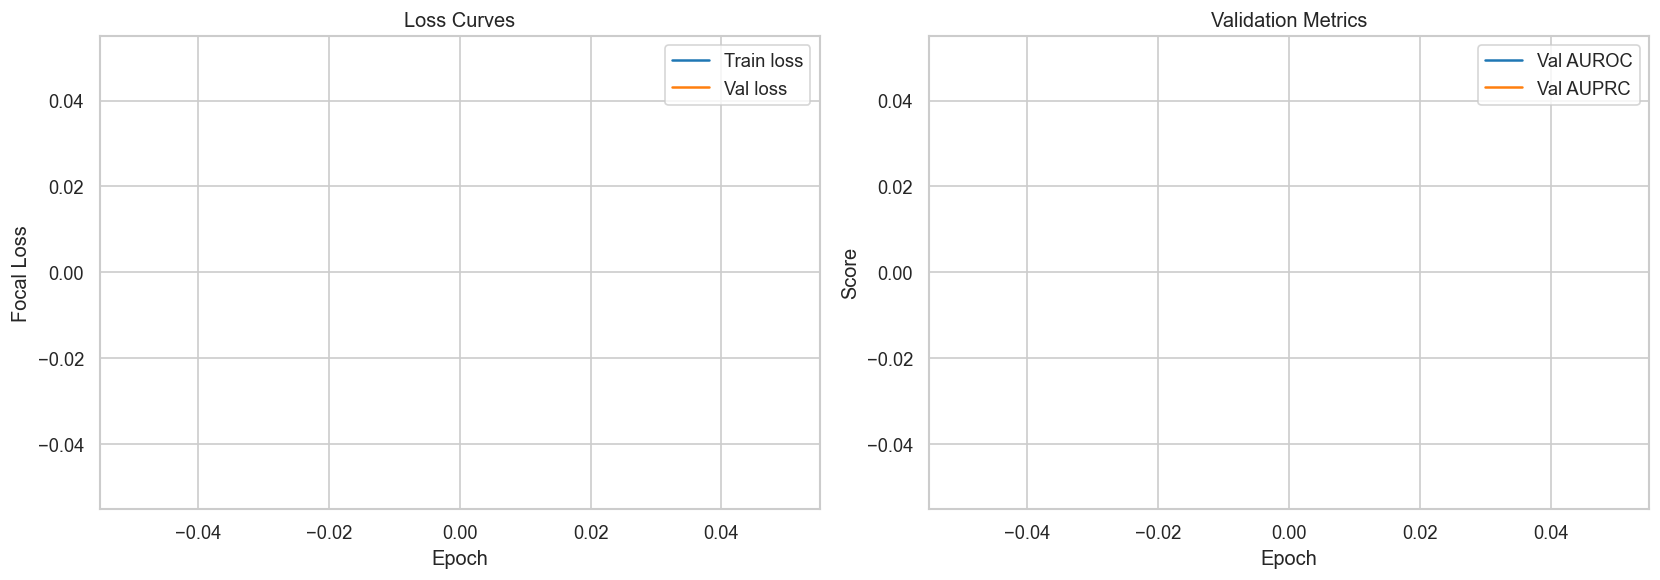

In [9]:
epochs_x = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_x, history["train_loss"], label="Train loss")
axes[0].plot(epochs_x, history["val_loss"], label="Val loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Focal Loss")
axes[0].set_title("Loss Curves")
axes[0].legend()

axes[1].plot(epochs_x, history["val_auroc"], label="Val AUROC")
axes[1].plot(epochs_x, history["val_auprc"], label="Val AUPRC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("Validation Metrics")
axes[1].legend()

plt.tight_layout()
plt.savefig("approach14_hybrid_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


  Test Results (CODE-15%) — threshold=0.487 (tuned on val)
  AUROC  : 0.8288  [0.8165 – 0.8419]
  AUPRC  : 0.4767  [0.4436 – 0.5104]
  F1     : 0.4368  [0.4179 – 0.4574]
  Sens   : 0.7492  [0.7213 – 0.7759]
  Spec   : 0.7379  [0.7268 – 0.7484]

  Sens>=0.90 thr: 0.409 -> Spec: 0.5387



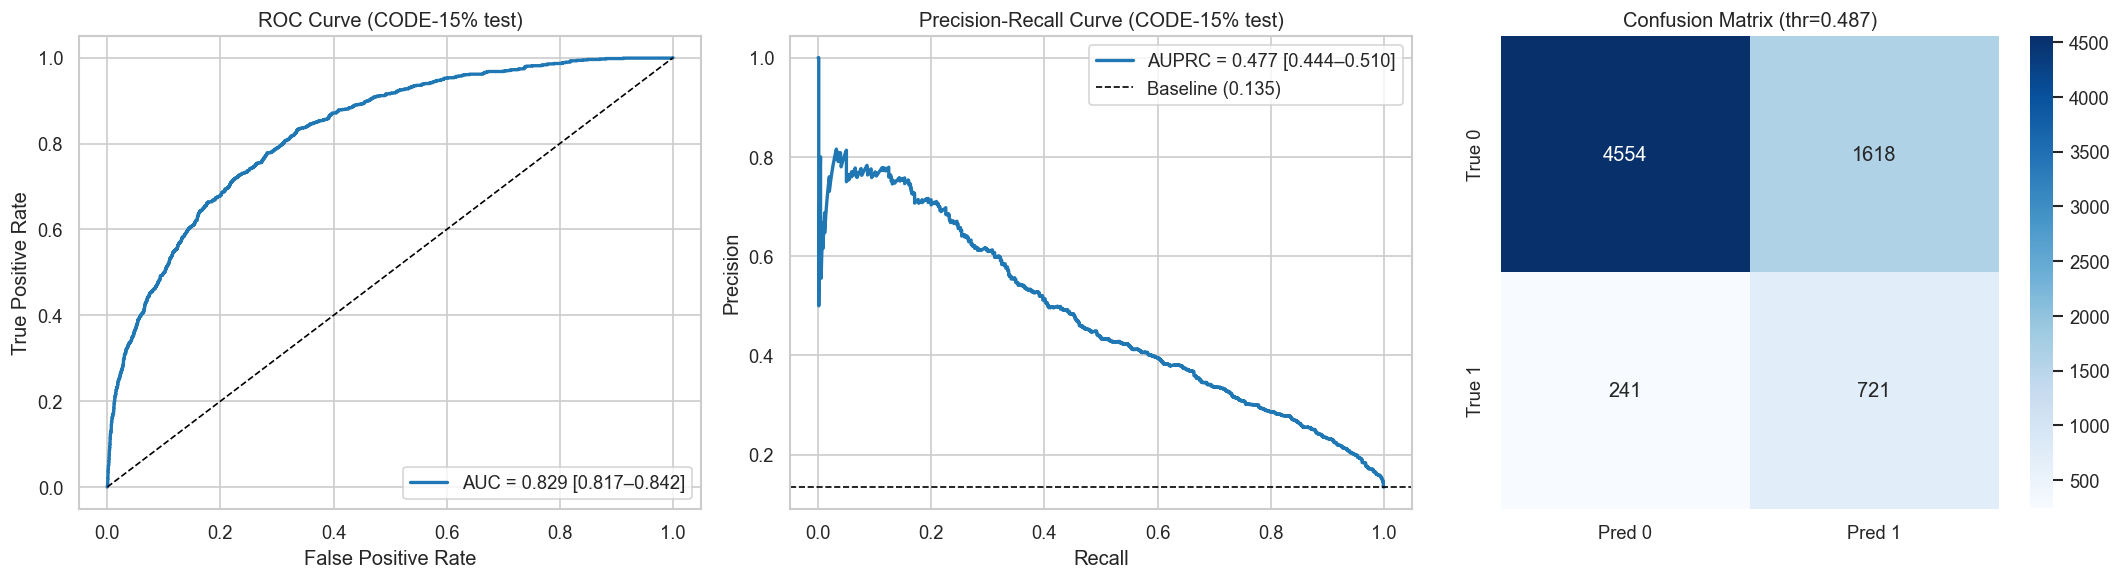

In [10]:
model.load_state_dict(torch.load("approach14_hybrid_code15_best.pt", weights_only=True))
_, _, test_targets, test_probs = evaluate(model, test_loader, criterion, device)

def _f1(yt, yp, thr):
    return f1_score(yt, (yp >= thr).astype(int), zero_division=0)

def _sens(yt, yp, thr):
    tn, fp, fn, tp = confusion_matrix(yt, (yp >= thr).astype(int), labels=[0, 1]).ravel()
    return tp / max(1, tp + fn)

def _spec(yt, yp, thr):
    tn, fp, fn, tp = confusion_matrix(yt, (yp >= thr).astype(int), labels=[0, 1]).ravel()
    return tn / max(1, tn + fp)

auroc_mean, auroc_lo, auroc_hi = bootstrap_ci(test_targets, test_probs, roc_auc_score)
auprc_mean, auprc_lo, auprc_hi = bootstrap_ci(test_targets, test_probs, average_precision_score)
f1_mean,   f1_lo,   f1_hi   = bootstrap_ci(test_targets, test_probs, lambda yt, yp: _f1(yt, yp, best_threshold))
sens_mean, sens_lo, sens_hi = bootstrap_ci(test_targets, test_probs, lambda yt, yp: _sens(yt, yp, best_threshold))
spec_mean, spec_lo, spec_hi = bootstrap_ci(test_targets, test_probs, lambda yt, yp: _spec(yt, yp, best_threshold))

print(f"\n{'='*60}")
print(f"  Test Results (CODE-15%) — threshold={best_threshold:.3f} (tuned on val)")
print(f"{'='*60}")
print(f"  AUROC  : {auroc_mean:.4f}  [{auroc_lo:.4f} – {auroc_hi:.4f}]")
print(f"  AUPRC  : {auprc_mean:.4f}  [{auprc_lo:.4f} – {auprc_hi:.4f}]")
print(f"  F1     : {f1_mean:.4f}  [{f1_lo:.4f} – {f1_hi:.4f}]")
print(f"  Sens   : {sens_mean:.4f}  [{sens_lo:.4f} – {sens_hi:.4f}]")
print(f"  Spec   : {spec_mean:.4f}  [{spec_lo:.4f} – {spec_hi:.4f}]")
print(f"{'='*60}\n")

def find_threshold_by_sensitivity(y_true, y_prob, target_sens=0.90):
    if len(np.unique(y_true)) < 2:
        return 0.5
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    idx = np.where(tpr >= target_sens)[0]
    if len(idx) > 0:
        return float(thresholds[idx[0]])
    return 0.5

sens_90_threshold = find_threshold_by_sensitivity(test_targets, test_probs, 0.90)
y_pred_sens90 = (test_probs >= sens_90_threshold).astype(int)
cm_sens90 = confusion_matrix(test_targets, y_pred_sens90, labels=[0, 1])
tn_90, fp_90, fn_90, tp_90 = cm_sens90.ravel()
spec_at_sens90 = tn_90 / max(1, tn_90 + fp_90)
print(f"  Sens>=0.90 thr: {sens_90_threshold:.3f} -> Spec: {spec_at_sens90:.4f}")
print(f"{'='*60}\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if len(np.unique(test_targets)) >= 2:
    fpr, tpr, _ = roc_curve(test_targets, test_probs)
    axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {auroc_mean:.3f} [{auroc_lo:.3f}–{auroc_hi:.3f}]")
    axes[0].plot([0, 1], [0, 1], "k--", lw=1)
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve (CODE-15% test)")
    axes[0].legend(loc="lower right")

    prec, rec, _ = precision_recall_curve(test_targets, test_probs)
    axes[1].plot(rec, prec, lw=2, label=f"AUPRC = {auprc_mean:.3f} [{auprc_lo:.3f}–{auprc_hi:.3f}]")
    pos_rate = test_targets.mean()
    axes[1].axhline(pos_rate, color="k", linestyle="--", lw=1, label=f"Baseline ({pos_rate:.3f})")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve (CODE-15% test)")
    axes[1].legend(loc="upper right")
else:
    axes[0].text(0.5, 0.5, 'ROC undefined\n(only 1 class in test set)', ha='center', va='center')
    axes[0].set_title("ROC Curve")
    axes[1].text(0.5, 0.5, 'PR undefined\n(only 1 class in test set)', ha='center', va='center')
    axes[1].set_title("Precision-Recall Curve")

y_pred = (test_probs >= best_threshold).astype(int)
cm = confusion_matrix(test_targets, y_pred, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
axes[2].set_title(f"Confusion Matrix (thr={best_threshold:.3f})")

plt.tight_layout()
plt.savefig("approach14_hybrid_test_results.png", dpi=150, bbox_inches="tight")
plt.show()

## SaMi-Trop external evaluation

SaMi-Trop contains 1,631 records, all Chagas+, so AUROC and AUPRC are undefined. It is evaluated as a standalone external cohort (different region, different acquisition device); we report sensitivity at the CODE-15 validation threshold and the distribution of predicted probabilities.

In [ ]:

import numpy as np
import torch
from torch.utils.data import DataLoader

assert len(samitrop_indices) > 0, (
    "samitrop_indices is empty. Check that the data-split cell ran correctly "
    "and that the SaMi-Trop CSV is present."
)

logger.info(
    f"SaMi-Trop OOD set: {len(samitrop_indices)} samples, "
    f"positive_rate={all_labels[samitrop_indices].mean():.3f}"
)

ds_samitrop = CachedChagasDataset(cache_file, samitrop_indices)
samitrop_loader = DataLoader(
    ds_samitrop,
    batch_size=CFG["batch_size"],
    shuffle=False,
    pin_memory=(device.type == "cuda"),
    num_workers=CFG["num_workers"],
)

ood_model = HybridFMPINN(fm_model, pinn_model).to(device)
ood_model.load_state_dict(
    torch.load("approach14_hybrid_code15_best.pt", map_location=device, weights_only=True)
)
ood_model.eval()
logger.info("Loaded approach14_hybrid_code15_best.pt for SaMi-Trop OOD inference")

ood_probs_list   = []
ood_targets_list = []

with torch.no_grad():
    for x_batch, y_batch in tqdm(samitrop_loader, desc="SaMi-Trop OOD inference"):
        x_batch = x_batch.to(device)
        logits  = ood_model(x_batch)
        probs   = torch.sigmoid(logits)
        ood_probs_list.extend(probs.cpu().numpy())
        ood_targets_list.extend(y_batch.numpy())

ood_targets = np.array(ood_targets_list, dtype=int)
ood_probs   = np.array(ood_probs_list,   dtype=float)

assert ood_targets.mean() == 1.0, f"Expected all-positive SaMi-Trop, got mean={ood_targets.mean():.3f}"

y_pred_ood   = (ood_probs >= best_threshold).astype(int)
sensitivity  = y_pred_ood.mean()
mean_prob    = ood_probs.mean()
median_prob  = float(np.median(ood_probs))
q25, q75     = float(np.percentile(ood_probs, 25)), float(np.percentile(ood_probs, 75))

print()
print("=" * 60)
print("  OOD Evaluation: SaMi-Trop (100% Chagas+, external)")
print(f"  N={len(ood_targets)} | threshold={best_threshold:.3f} (Youden on CODE-15% val)")
print("=" * 60)
print(f"  Sensitivity (detection rate) : {sensitivity:.4f}")
print(f"  Mean predicted probability   : {mean_prob:.4f}")
print(f"  Median predicted probability : {median_prob:.4f}")
print(f"  IQR                          : [{q25:.4f} {q75:.4f}]")
print("=" * 60)
print()
print("AUROC/AUPRC undefined (single-class set).")
print(f"Baseline CODE-15% val AUROC: {max(history['val_auroc'], default=float('nan')):.4f}")
print()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ood_probs, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(best_threshold, color="tomato", linestyle="--", lw=2, label=f"threshold={best_threshold:.3f}")
ax.axvline(mean_prob,      color="green",  linestyle=":",  lw=2, label=f"mean={mean_prob:.3f}")
ax.set_xlabel("Predicted Chagas probability")
ax.set_ylabel("Count")
ax.set_title(f"SaMi-Trop OOD: score distribution (N={len(ood_probs)}, all Chagas+)")
ax.legend()
plt.tight_layout()
plt.savefig("approach14_hybrid_samitrop_ood.png", dpi=150, bbox_inches="tight")
plt.show()

logger.info("SaMi-Trop OOD evaluation complete. Saved: approach14_hybrid_samitrop_ood.png")